Jumlah objek: 4


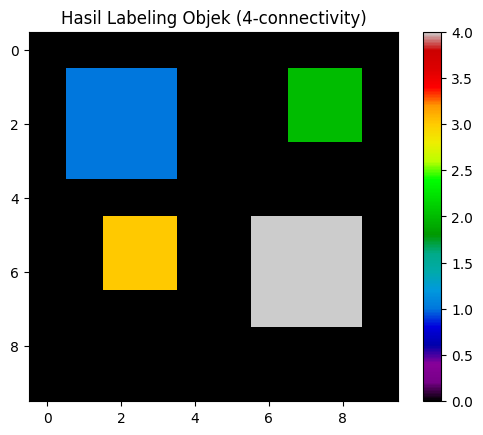

In [1]:
#JAWABAN NO. 1
import numpy as np
import matplotlib.pyplot as plt

img = np.array([
[0,0,0,0,0,0,0,0,0,0],
[0,1,1,1,0,0,0,1,1,0],
[0,1,1,1,0,0,0,1,1,0],
[0,1,1,1,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0],
[0,0,1,1,0,0,1,1,1,0],
[0,0,1,1,0,0,1,1,1,0],
[0,0,0,0,0,0,1,1,1,0],
[0,0,0,0,0,0,0,0,0,0],
[0,0,0,0,0,0,0,0,0,0]
])

rows, cols = img.shape
visited = np.zeros((rows,cols))
label_img = np.zeros((rows,cols))

# arah 4-connectivity
directions = [(-1,0),(1,0),(0,-1),(0,1)]

def dfs(x,y,label):

    stack = [(x,y)]
    visited[x,y] = 1
    label_img[x,y] = label

    while stack:
        cx,cy = stack.pop()

        for dx,dy in directions:
            nx,ny = cx+dx, cy+dy

            if 0<=nx<rows and 0<=ny<cols:
                if img[nx,ny]==1 and visited[nx,ny]==0:

                    visited[nx,ny]=1
                    label_img[nx,ny]=label
                    stack.append((nx,ny))

label = 0

for i in range(rows):
    for j in range(cols):

        if img[i,j]==1 and visited[i,j]==0:
            label += 1
            dfs(i,j,label)

print("Jumlah objek:", label)

#menampilkan gambar
plt.imshow(label_img, cmap='nipy_spectral')
plt.title("Hasil Labeling Objek (4-connectivity)")
plt.colorbar()
plt.show()

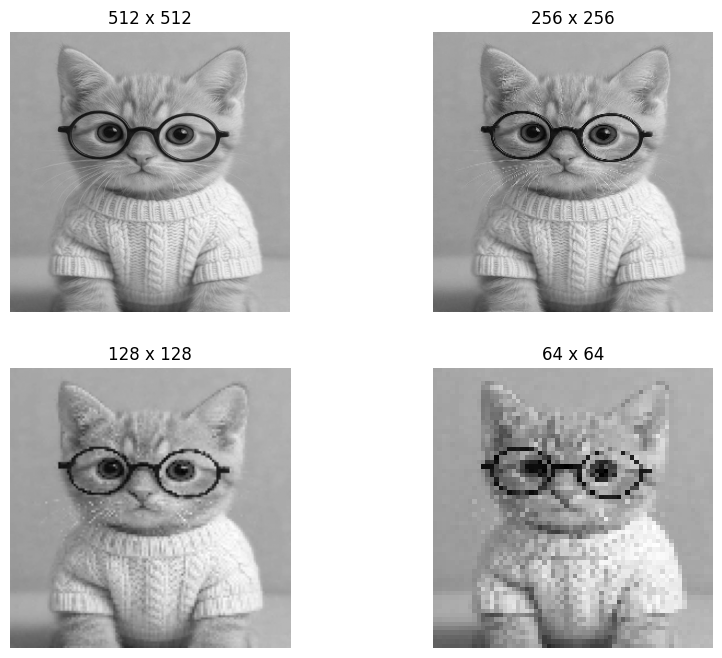

In [2]:
#JAWABAN NO. 2
import cv2
import matplotlib.pyplot as plt

# baca gambar
img = cv2.imread("kucing.jpg", cv2.IMREAD_GRAYSCALE)

sizes = [512,256,128,64]

plt.figure(figsize=(10,8))

for i,size in enumerate(sizes):

    resized = cv2.resize(img,(size,size))

    plt.subplot(2,2,i+1)
    plt.imshow(resized,cmap='gray')
    plt.title(f"{size} x {size}")
    plt.axis('off')

plt.show()

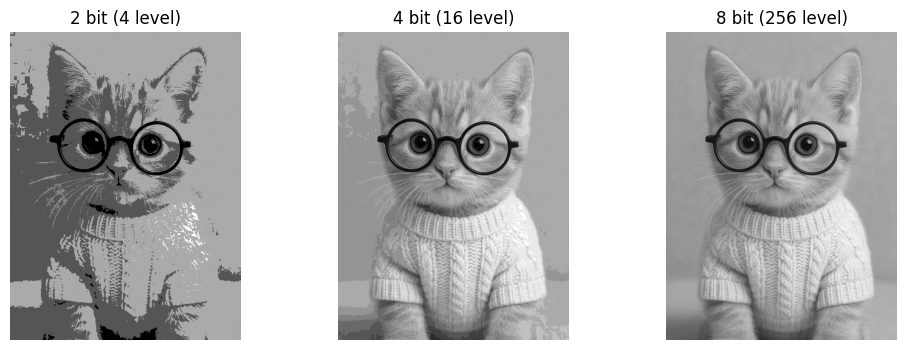

In [4]:
#JAWABAN NO. 3
import cv2
import numpy as np
import matplotlib.pyplot as plt

# membaca gambar grayscale
img = cv2.imread("kucing.jpg", cv2.IMREAD_GRAYSCALE)

# fungsi kuantisasi
def quantization(image, bits):

    levels = 2 ** bits      # jumlah level
    max_val = 256

    step = max_val / levels

    quantized = np.floor(image / step) * step
    quantized = quantized.astype(np.uint8)

    return quantized

# kuantisasi
q2 = quantization(img,2)   # 2 bit
q4 = quantization(img,4)   # 4 bit
q8 = quantization(img,8)   # 8 bit

# tampilkan hasil
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(q2,cmap='gray')
plt.title("2 bit (4 level)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(q4,cmap='gray')
plt.title("4 bit (16 level)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(q8,cmap='gray')
plt.title("8 bit (256 level)")
plt.axis('off')

plt.show()